# MDP 和 贝尔曼最优方程

M=(S,A,P,R,γ)（MDP 五元组：描述序列决策问题）

马尔可夫决策过程 (Markov Decision Process)：

S：状态空间（State Space），所有可能局面的集合。

A：动作空间（Action Space），所有可能采取的操作的集合。

| 动作空间 | 特点 | 适用算法 |
| :--- | :--- | :--- |
| 离散（如 `{左, 右}`） | 可枚举所有选择，挑最好的 | Q-learning / DQN， 其中两者都使用的是确定性策略，因此DQN经常搭配贪婪算法来增加探索程度|
| 连续（如关节力矩） | 无法枚举 | 策略梯度（PPO 等），输出动作的概率分布，因此自带是随机性的 |



P：状态转移概率（Transition Probability），描述环境的物理规律。

R：奖励函数（Reward Function），描述环境对动作的打分规则。

γ：折扣因子（Discount Factor）γ∈[0,1] ，决定智能体有多”短视”或”远视”。

> 折旧因子**数学上的必要性**
>
> 在无限期游戏中，如果 CartPole 永远活下去，每步都拿 `+1`：
> $$G_t = 1 + 1 + 1 + \cdots = \infty$$
>
> 两个永远活着的策略总回报都是 $\infty$，无法比较，优化无从谈起。折扣因子让每步奖励递减，保证累积奖励收敛到有限值。当 $\gamma < 1$ 且 $|R| \le R_{\max}$ 时：
> $$G_t \le R_{\max} \sum_{k=0}^{\infty} \gamma^k = \frac{R_{\max}}{1 - \gamma}$$

# 强化学习核心概念：以大学生求职为例

## 状态价值 $V(s)$和动作价值$Q(s, 动作)$

假设你站在迷宫的起点 $s$：

- **算 $V(s)$**：你会看所有可能的动作（上、下、左、右），按照当前策略的概率，算出一个加权平均的总回报。
- **算 $Q(s, \text{向上})$**：你强制第一步只能“向上”走。第一步走完之后，后续的路再按照当前策略的概率去算总回报。

例子：

假设你现在面临大学毕业找工作（当前状态 $s$）：

- **状态价值 $V(s)$**：评估的是你作为“应届毕业生”这个身份的整体期望薪资。比如你评估自己大概率能拿到 10k 左右。这取决于你的学校、专业、面试表现等综合因素。
- **动作价值 $Q(s, a)$**：评估的是你在当前状态下，做出具体选择的期望薪资。
  - $Q(s, \text{去大厂})$：去大厂起薪可能只有 8k，但未来三年涨薪快，总回报可能是 100w。
  - $Q(s, \text{去国企})$：去国企起薪 6k，但稳定，总回报可能是 80w。
  - $Q(s, \text{考研})$：考研这两年没工资，但三年后毕业，总回报可能是 120w。

你会发现，$V(s)$ 其实就是你所有 $Q(s, a)$ 按照你当前倾向的加权平均值：

$$V(s) = \sum \pi(a|s) \cdot Q(s, a)$$


## 其他概念

1. **状态（State, $s$）**
   你当前的客观处境：即将毕业的大学生。

2. **动作（Action, $a$）**
   你手里的选项：
   - $a_1$ = 去大厂
   - $a_2$ = 去国企
   - $a_3$ = 考研

3. **策略（Policy, $\pi$）**
   你心里的倾向（概率表）：
   - $\pi(a_1|s) = 0.7$ （你心里有 70% 的倾向想去大厂）
   - $\pi(a_2|s) = 0.2$ （20% 的倾向去国企）
   - $\pi(a_3|s) = 0.1$ （10% 的倾向去考研）

4. **奖励（Reward, $r$）**
   你做出选择后得到的即时反馈：比如去大厂第一个月发了 2 万工资，奖励就是 +20000；如果考研第一年没考上，奖励就是 -1000。

5. **回报（Return, $G_t$）**
   从当前时刻开始，未来所有奖励的累积总和（通常会乘以一个折扣因子 $\gamma$，表示未来的钱不如现在的钱值钱）。
   > **例子解释**：假设你选了“去大厂”，第一年的工资奖励是 20万，第二年涨薪奖励是 25万。如果折扣因子 $\gamma = 0.9$（代表你更看重眼前的钱），那么你这趟求职的“回报”大约是：$G_t = 20万 + 0.9 \times 25万 = 42.5万$。它代表了“长远来看，我选了这条路走下去，总共能拿多少好处”。

   $$G_t = R_{t+1} + \gamma (R_{t+2} + \gamma R_{t+3} + \dots)$$
   $$G_t = R_{t+1} + \gamma G_{t+1}$$
   
   含义： “当前时刻的回报”等于“下一步立马能拿到的奖励”加上“下一步的回报打个折”。

6. **动作价值（Action-Value, $Q$）**
   你是大学生，然后采取“去大厂”这个特定动作后的预期长期回报。
   > **例子解释**：$Q(\text{去大厂})$ 就是评估“只要我头铁去大厂，长远来看平均能赚多少钱”。

7. **状态价值（State-Value, $V$）**
   基于你当前是“大学生”这个状态，按照你心里的倾向（策略）去随机选，平均下来能得到的长期回报。
   > **例子解释**：$V(\text{大学生})$ 就是评估“作为一个普通应届生，按你 70%大厂、20%国企、10%考研的概率去选，长远来看平均能赚多少钱”。

8. **优势函数（Advantage, $A(s,a)$）**
   用来衡量“我选的这条路，比平均水平好多少（或差多少）”的指标。它的公式极其简单：

   $$
   A(s,a) = Q(s,a) - V(s)
   $$

   > **例子解释**：如果 $Q(\text{去大厂}) = 100$，而你作为大学生的平均预期 $V = 80$，那么 $A = 100 - 80 = +20$。说明去大厂比平均水平好 20 分，你应该增加去大厂的概率！



   

# Q如何由未来的V和即时奖励R组成？

$Q(s, \text{去大厂})$ 是评估去大厂长远能赚多少钱。
实际上，去大厂这个动作发生后，会产生两部分结果，这也是你笔记中 MDP 五元组里 $P$ 和 $R$ 发挥作用的地方：  眼前的即时奖励 ($R$)： 比如你拿到了入职签字费和第一个月的工资（假设是 3 万）。未来的状态转移 ($P$)： 你去大厂后，你的身份（状态）变了！你不再是“应届毕业生($s$)”，你变成了“大厂新人($s'$)”。但是现实有概率（也就是状态转移概率 $P$），比如：90% 的概率顺利转正，进入状态 $s_1'$（大厂正式工）。10% 的概率试用期被裁，进入状态 $s_2'$（失业游民）。那么，$Q(s, \text{去大厂})$ 到底等于多少？
它就等于：眼前的奖励 + 折扣因子 $\gamma$ $\times$ 未来状态的期望价值。  写成通俗的数学公式就是：$$Q(s, a) = R(s,a) + \gamma \sum_{s'} P(s' | s, a) \cdot V(s')$$通俗解释： 选择去大厂的长期价值 = 眼前拿到的 3 万块钱 + $\gamma$ $\times$ (90% $\times$ 大厂正式工的长期价值 $V(s_1')$ + 10% $\times$ 失业游民的长期价值 $V(s_2')$)。

## P绝对不是 $\pi$。

在强化学习中，$\pi$ 和 $P$ 代表着两个完全不同角色的决定权。我们可以把整个过程看作是“你（智能体）”和“大自然（环境）”在下棋。为了帮你彻底理清，我们来拆解这两个符号背后的真正含义：

### 1. $\pi$ 是“你”的意志（策略 Policy）

- **是谁在做决定？** 智能体（Agent）。
- **它代表什么？** 在状态 $S$ 下，你主观上想要采取某个动作的概率。
- **对应公式：** $\pi(a \mid S)$

**在你的例子中：** $\pi(\text{右} \mid S) = 0.8$。意思是，站在走廊位置 $S$，你经过思考后，决定有 80% 的意愿向右走。这个 0.8 完全取决于你的“大脑”或算法偏好。

### 2. $P$ 是“大自然”的物理规律（状态转移概率 Transition Probability）

- **是谁在做决定？** 环境（Environment / 游戏引擎）。
- **它代表什么？** 当你决定并执行了某个动作后，客观世界发生结果的概率。
- **对应公式：** $P(s' \mid S, a)$

**在你的例子中：** $P(M \mid S, \text{右}) = 1$。意思是，当你（在 $S$）确实迈出了向右的脚步（动作 $a$），环境的物理规则决定了你有 100% 的概率会到达下一个位置 $M$。

---

### 💡 为什么你会产生这种错觉？

因为在你给出的这个“走廊”例子中，环境是完美的（确定性的）。你往右走，就 100% 会到达右边的格子（$P=1$）。当 $P=1$ 的时候，公式里的乘法 $1 \cdot V_{old}$ 让人感觉 $P$ 好像不存在一样，所有的概率变化似乎都只受 $\pi$（0.8 和 0.2）的影响。

让我们换一个稍微复杂的场景，你就立刻明白了：

假设这是一条**结冰的走廊**（也就是环境具有随机性/滑行效应）。
- 你的策略 $\pi$ 没变：你依然有 80% 的意愿想往右走，即 $\pi(\text{右} \mid S) = 0.8$。
- 但是环境的物理规则 $P$ 变了：由于地太滑，即便你努力往右走，你只有 90% 的概率成功到达右边的 $M$；有 10% 的概率脚底打滑，摔倒在了原地 $S$。

# 推箱子游戏

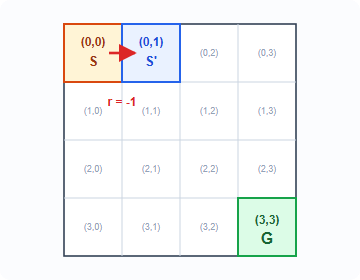

对于上述推箱子游戏，从左上角推到右下角，用两种方式进行更新，一个是贝尔曼最优方程，另外一个是Q-Learning来更新

# 贝尔曼最优方程 (Bellman Optimality Equation) 的两种应用形态

在学术上，状态用 $s$ (state)，动作用 $a$ (action)，下一个状态用 $s'$ (next state)，即时奖励用 $R$ 或 $r$ (reward)。

---

## 1. 已知环境：基于模型的动态规划（如：价值迭代 Value Iteration）

由于 Agent 拥有“上帝视角”，掌握了环境的完整运转模型（即知道状态转移概率 $P$ 和 奖励函数 $R$），它可以无需真实交互，直接在纸上计算出最优的全局策略。因为是直接通过代数迭代求精确解，所以**不需要“学习率”**。

### 状态价值更新公式 (V-value update)

$$
V_{k+1}(s) \leftarrow \max_{a} \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(s') \right]
$$

### 符号说明

- **$V_k(s)$**：第 $k$ 次迭代时，状态 $s$ 的价值。
- **$R(s,a)$**：在状态 $s$ 执行动作 $a$ 能获得的期望奖励（也就是代码里的 `get_reward`）。
- **$P(s'|s,a)$**：转移概率。在确定性网格里它等于 1（必定能走到 $s'$），所以我们在代码里省略了求和 $\sum$ 这一步；但在复杂环境（如地面打滑）中，走一步可能会按概率滑到不同格子。
- **$\gamma$**：折扣因子 (Discount factor)。

### 核心特征

包含 $\sum P(s'|s,a)$ 和 $R(s,a)$，这意味着算法必须**直接调用环境底层的客观规律**。

---

## 2. 未知环境：无模型的时序差分学习（如：Q-Learning）

由于 Agent 处于未知环境（无法调用 $P$ 和 $R$ 函数），它不能在脑子里推算未来，必须亲自用肉身去与环境交互（试错），获得一条真实的经验样本 $(s, a, r, s')$。因为它是用一次次的“偶然样本”去逼近真实的数学期望，所以**必须引入 $\alpha$ (学习率)**，来控制每次从误差中吸取教训的幅度。

### 动作价值更新公式 (Q-value update)

$$\begin{align*}
Q_{new}(s,a) &= \underbrace{Q(s,a) + \alpha \Big[ \overbrace{r + \gamma \max_{a'} Q(s',a')}^{\text{TD Target}} - Q(s,a) \Big]}_{\text{形态一：基于 "TD误差" 的修正逻辑 (代码最常用)}} \\
\\
&= \underbrace{(1 - \alpha) Q(s,a) + \alpha \Big( \overbrace{r + \gamma \max_{a'} Q(s',a')}^{\text{TD Target}} \Big)}_{\text{形态二：基于 "加权平均" 的平滑逻辑 (最容易理解本质)}}
\end{align*}$$

### 符号说明

- **$Q(s, a)$**：当前经验表（Q表）中，对“在状态 $s$ 执行动作 $a$”的价值估算。
- **$r$**：亲自执行一步动作后，环境实际返回的具体奖励值（它是公式 1 中 $R(s,a)$ 的一个实际抽样）。
- **$s'$**：亲自执行一步动作后，环境实际返回的下一个状态（它是公式 1 中受 $P$ 概率控制的一个实际发生结果）。
- **$\max_{a'} Q(s', a')$**：到达 $s'$ 后，根据现有的 Q 表，预估未来能拿到的最大价值。
- **$\alpha$**：学习率 (Learning rate)，取值通常在 $(0, 1]$ 之间。

## 价值迭代收敛代码

In [ ]:
import numpy as np

# ==========================================
# 第一部分：搭建“已知环境”的物理规则 (环境模型 Model)
# 因为是已知环境，所以算法拥有“上帝视角”，能随时查看这些规则
# ==========================================
GRID = 4
ACTIONS = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # 动作空间：右、左、下、上
GAMMA = 0.99         # 折扣因子 (打折率)：决定了眼前的利益和未来的利益哪个更重要
STEP_REWARD = -0.01  # 步进惩罚：每走一步扣一点分，逼迫算法寻找“最短路径”

def is_terminal(s):
    # 判断是否到达游戏结束的状态
    return s == (3, 3) or s == (1, 1)  # (3,3)是目标G, (1,1)是陷阱X

def get_reward(s):
    # 奖励函数 R(s)：这就是已知环境的特权，能直接查到任何格子的得分
    if s == (3, 3): return 1.0   # 到达终点，大奖
    if s == (1, 1): return -1.0  # 掉进陷阱，大惩罚
    return STEP_REWARD           # 普通格子，扣除走路消耗

def next_state(s, a):
    # 状态转移函数 P(s'|s,a)：提前在脑子里推演未来。
    # 比如在(0,0)往右走，不用真走，调用这个函数就知道会到(0,1)
    ns = (s[0] + a[0], s[1] + a[1])
    # 边界检测：如果没越界就返回新坐标，撞墙了就留在原地
    if 0 <= ns[0] < GRID and 0 <= ns[1] < GRID:
        return ns
    return s  

# ==========================================
# 第二部分：核心算法 - 价值迭代 (Value Iteration)
# 纯靠大脑推演（算 V 值），不需要智能体去实体试错
# ==========================================
def value_iteration(n_iters=100):
    # 初始化地段估价表 V (State-Value Table)
    # 一开始大家都不知道迷宫长啥样，全部猜 0
    V = np.zeros((GRID, GRID)) 
    
    for it in range(n_iters):
        # 准备一张新图 V_new，用来装这一轮算出来的最新分数
        V_new = V.copy()
        
        # 开启上帝视角，直接暴力扫描地图上的每一个格子
        for i in range(GRID):
            for j in range(GRID):
                s = (i, j)
                
                # 如果这个格子已经是终点或陷阱了，直接把固定分数写上去，不用再往后推演了
                if is_terminal(s):
                    V_new[i, j] = get_reward(s)
                    continue
                
                # ---------------------------------------------------
                # ★ 核心魔法：直接套用贝尔曼最优方程 ★
                # 公式：V(s) = max_a [ R(s,a) + γ * V(s') ]
                # ---------------------------------------------------
                values = [] # 用来装 4 个方向的预期总得分
                
                for a in ACTIONS:
                    # 1. 脑内推演：如果走动作 a，下一步会到哪 (s')？
                    ns = next_state(s, a)
                    
                    # 2. 查阅奖励：走到那一步，立刻能拿到多少分 (R)？
                    r = get_reward(ns) if is_terminal(ns) else STEP_REWARD
                    
                    # 3. 查阅未来：下一个格子本身的值多少钱 (V(s'))？
                    # 4. 计算预期：眼前奖励 + 打折后的未来价值
                    expected_value = r + GAMMA * V[ns[0], ns[1]]
                    
                    values.append(expected_value)
                
                # 5. 取最大值：在 4 个方向的预期得分里，挑一个最高的，作为当前格子的最新身价！
                V_new[i, j] = max(values)
                
        # 一轮扫描结束，把算好的新图替换掉旧图，准备下一轮“扩散”
        V = V_new 
        
    return V # 100 轮后，返回收敛的完美估价表

# 运行算法并打印结果
V = value_iteration(100)
print(V)

## 时序差分学习Q-Learning

In [1]:
import random
import numpy as np

# ==========================================
# 核心算法 - Q-Learning (无模型/未知环境)
# 智能体没有上帝视角，必须靠“肉身试错”来积累经验
# ==========================================
class QLearningAgent:
    def __init__(self, alpha=0.1, gamma=0.99, epsilon=0.1):
        # 初始化 Q 表 (Q-Table)：智能体的“经验账本”
        # 形状是 4x4x4，代表 4x4 的地图里，每个格子都有 4 个动作的打分。一开始全是 0（无知状态）
        self.Q = np.zeros((GRID, GRID, 4))  
        
        self.alpha = alpha     # 学习率：被现实打脸后，每次修正认知的幅度 (0.1代表只吸收10%的新经验)
        self.gamma = gamma     # 折扣因子：未来的大奖在今天值多少钱
        self.epsilon = epsilon # 探索率：有多大概率去“瞎走”尝试新事物
    
    def select_action(self, s):
        # ---------------------------------------------------
        # ★ 探索与利用困境 (Exploration vs Exploitation) ★
        # ---------------------------------------------------
        if random.random() < self.epsilon:
            # 探索 (Explore)：掷骰子，10% 的概率瞎选一个方向。
            # 为了防止智能体一开始碰巧找到一条次优路线就沾沾自喜，必须强迫它偶尔试试别的路
            return random.randint(0, 3)  
            
        # 利用 (Exploit)：90% 的概率查阅 Q 表，挑当前格子里分数最高的动作走
        return np.argmax(self.Q[s[0], s[1]])  
    
    def update(self, s, a, r, s_next, done):
        # ---------------------------------------------------
        # ★ 核心魔法：时序差分 (TD) 更新公式 ★
        # 公式：Q(s,a) = Q(s,a) + alpha * [ r + gamma * max_Q(s') - Q(s,a) ]
        # ---------------------------------------------------
        
        # 1. 计算 TD 目标 (TD Target)：现实的真实体验
        # 如果游戏结束(done)，未来收益就是0；否则，未来收益是下一个格子里的最高 Q 值
        future_q = 0 if done else np.max(self.Q[s_next[0], s_next[1]])
        td_target = r + self.gamma * future_q 
        
        # 2. 计算 TD 误差 (TD Error)：现实体验与我原本认知的差距
        # td_target 是“实际发生的事”，self.Q[...] 是“我以前以为的事”
        td_error = td_target - self.Q[s[0], s[1], a]
        
        # 3. 更新 Q 表：用误差来修正旧观念
        self.Q[s[0], s[1], a] += self.alpha * td_error

# ==========================================
# 游戏模拟器：把智能体扔进环境里不断循环挨打/吃糖
# ==========================================
def run_episode(agent, max_steps=100):
    s = (0, 0)  # 每一局游戏，智能体都从左上角起点出生
    total_reward = 0
    
    for step in range(max_steps):
        # 1. 智能体根据自己的脑子（Q表）决定迈出哪一步
        a_idx = agent.select_action(s)
        a = ACTIONS[a_idx]
        
        # 2. 环境（黑盒）响应该动作，告诉智能体：你到了哪，拿了多少分，死了没
        # 注意：这里调用了环境函数，但 agent 内部是看不见这些函数的，它只能被动接受结果
        ns = next_state(s, a)
        done = is_terminal(ns)
        r = get_reward(ns) if done else STEP_REWARD
        
        # 3. 智能体拿到了真实的体验数据 (s, a, r, ns, done)，赶紧记在小本本上，更新大脑
        agent.update(s, a_idx, r, ns, done)
        
        total_reward += r
        
        # 4. 如果踩到陷阱或到达终点，这局游戏直接结束
        if done: break
            
        # 5. 走到下一个格子，继续循环
        s = ns
        
    return total_reward

# 实例化一个“无知”的智能体
agent = QLearningAgent()
rewards = []

# 强迫智能体在这个世界里轮回 2000 次！
# 前 100 次它可能一直在踩陷阱，但慢慢地它脑子里的 Q 表就收敛到真理了
for episode in range(2000):
    r = run_episode(agent)
    rewards.append(r)

NameError: name 'GRID' is not defined